In [1]:
import cooltools
import cooler
from tqdm import tqdm
from os.path import basename, splitext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections.abc import Iterable
import bioframe
import gc
import subprocess
import itertools
import pysam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import seaborn as sns

### Load Hi-C cool files of replicates (50kb resolution) and reference FASTA GRCm38 file

In [2]:
data_dir = '/tank/projects/kashuk_sirt6_hic/coolers/'
wt1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_2_50k.cool'))
wt2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_3_50k.cool'))
wt3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_m_1_50k.cool'))

old1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_2_50k.cool'))
old2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_3_50k.cool'))
old3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_m_1_50k.cool'))

ko1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_2_50k.cool'))
ko2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_3_50k.cool'))
ko3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_m_1_50k.cool'))

ref_fasta = ('/tank/projects/kashuk_sirt6_hic/GRCm38.p6.genome.fa')

### Calculate eigenvectors and eigenvalues 

In [3]:
def get_eigenvectors(clrs, ref_fasta='GRCm38.p6.genome.fa'):
    full_eigs = []
    eigenvectors = []
    if not isinstance(clrs, Iterable):
        clrs = tuple(clrs)
    for clr in clrs:
        bins = clr.bins()[:]
        ref_genome = bioframe.load_fasta(ref_fasta)
        gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)
        view_df = pd.DataFrame({'chrom': clr.chromnames,
                                'start': 0,
                                'end': clr.chromsizes.values,
                                'name': clr.chromnames}
                              )
        cis_eigs = cooltools.eigs_cis(clr, gc_cov, view_df=view_df, n_eigs=8, clr_weight_name='weight')
        full_eigs.append(cis_eigs)
        eigenvectors.append(cis_eigs[1][['chrom','start','end','E1','E2','E3','E4','E5','E6','E7','E8']])
    return full_eigs, eigenvectors

In [4]:
full_eigs, eigenvectors = get_eigenvectors((wt1, wt2, wt3, old1, old2, old3, ko1, ko2, ko3), ref_fasta=ref_fasta)
wt1_eigs, wt2_eigs, wt3_eigs, old1_eigs, old2_eigs, old3_eigs, ko1_eigs, ko2_eigs, ko3_eigs = eigenvectors

In [6]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


### Identification of regions demonstrating significant alterations in PC1 values  via posterior probability

In [12]:
%%R

library(reticulate)
library(limma)
library(ChIPpeakAnno)
library(TxDb.Mmusculus.UCSC.mm10.ensGene)
library(ChIPseeker)
library(clusterProfiler)
library(biomaRt)
library(stringr)
library(tidyverse)
library(org.Mm.eg.db)

process_eigs_data <- function(tr_prefix, set_name,
                              pp_threshold = 0.9,
                              change_threshold = 0.3) {
  # Load data
  wt1 <- py_eval('wt1_eigs')
  wt2 <- py_eval('wt2_eigs')
  wt3 <- py_eval('wt3_eigs')
  
  tr1 <- py_eval(paste0(tr_prefix, '1_eigs'))
  tr2 <- py_eval(paste0(tr_prefix, '2_eigs'))
  tr3 <- py_eval(paste0(tr_prefix, '3_eigs'))
  
  # Filter out chrX, Y, M
  filter_chrX <- function(df) df %>% filter(!grepl('chr[XMY]', chrom))
  wt1 <- filter_chrX(wt1); wt2 <- filter_chrX(wt2); wt3 <- filter_chrX(wt3)
  tr1 <- filter_chrX(tr1); tr2 <- filter_chrX(tr2); tr3 <- filter_chrX(tr3)
  
  # Create composite key
  wt1$comp <- paste(wt1$chrom, wt1$start, wt1$end, sep = "-")
  
  # Build matrix
  m <- as.matrix(cbind(tr1[,4], tr2[,4], tr3[,4], wt1[,4], wt2[,4], wt3[,4]))
  rownames(m) <- wt1$comp
  colnames(m) <- c('tr1', 'tr2', 'tr3', 'wt1', 'wt2', 'wt3')
  m <- m[!rowSums(is.na(m)), ]
  
  # ── Design matrix 
  d <- model.matrix(~ condition,
                    data = data.frame(
                      condition = factor(
                        c("tr","tr","tr","wt","wt","wt"),
                        levels = c("wt", "tr")  
                      )
                    ))

  print(d)
  
  # ── Fit limma + empirical Bayes 
  fit <- lmFit(m, d)
  e   <- eBayes(fit)
  
  # ── Posterior probability 
  # B-statistic = log posterior odds
  lods        <- e$lods[, "conditiontr"]
  post_prob   <- exp(lods) / (1 + exp(lods))
  post_effect <- e$coefficients[, "conditiontr"]  # posterior mean Δ PC1 
  
  df <- as.data.frame(m)
  df$comp        <- rownames(df)
  df$p.value     <- e$p.value[, "conditiontr"]
  df$post_prob   <- post_prob
  df$post_effect <- post_effect
  df$lods        <- lods
  
  # ── Filter by posterior probability 
  df_filt <- df[df$post_prob > pp_threshold, ]
  
  # ── Compute changes 
  df_filt$change1 <- abs(df_filt$tr1 - df_filt$wt1)
  df_filt$change2 <- abs(df_filt$tr2 - df_filt$wt2)
  df_filt$change3 <- abs(df_filt$tr3 - df_filt$wt3)
  df_filt$change  <- rowMeans(df_filt[, c('change1','change2','change3')], na.rm = TRUE)
  df_filt$wt      <- rowMeans(df_filt[, c('wt1','wt2','wt3')], na.rm = TRUE)
  df_filt$tr      <- rowMeans(df_filt[, c('tr1','tr2','tr3')], na.rm = TRUE)
  
  df_filt$direction <- case_when(
    df_filt$wt > 0 & df_filt$tr < 0 ~ "A_to_B",
    df_filt$wt < 0 & df_filt$tr > 0 ~ "B_to_A",
    df_filt$post_effect > 0          ~ "A_stronger",
    df_filt$post_effect < 0          ~ "B_stronger",
    TRUE                             ~ "ambiguous"
  )
  
  # ── Filter by effect size 
  df_filt[c('chr', 'start', 'end')] <- str_split_fixed(df_filt$comp, "-", 3)
  final_df <- df_filt[df_filt$change > change_threshold, ]

  # ── Annotate genomic regions 
  gr <- GRanges(seqnames = final_df$chr,
                ranges = IRanges(start = as.numeric(final_df$start),
                                 end   = as.numeric(final_df$end)))
  
  peakAnno <- annotatePeak(gr,
                           TxDb = TxDb.Mmusculus.UCSC.mm10.ensGene,
                           annoDb = "org.Mm.eg.db",
                           addFlankGeneInfo = TRUE,
                           flankDistance = 10000)
  ann <- as.data.frame(peakAnno)
  
  final_df$gene_id  <- ann$geneId
  final_df$symbol   <- ann$SYMBOL
  final_df$genename <- ann$GENENAME
  final_df$flank    <- ann$flank_geneIds
  
  return(final_df)
}


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    ── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.0.2
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks clusterProfiler::filter(), stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Posit

Loading required package: IRanges
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following object is masked from ‘package:limma’:

    plotMA

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors
Loading required package: stats4

Attaching package: ‘S4Vectors’

The following object is masked from ‘package:utils’:

    findMatches

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package:

In [13]:
## posterior probability > 0.9 and a minimum absolute change of 0.3 in PC1 value

In [15]:
%%R

final_df_old <- process_eigs_data("old", "Old", pp_threshold = 0.9, change_threshold = 0.3)
final_df_ko  <- process_eigs_data("ko",  "S6-KO", pp_threshold = 0.9, change_threshold = 0.3)

  (Intercept) conditiontr
1           1           1
2           1           1
3           1           1
4           1           0
5           1           0
6           1           0
attr(,"assign")
[1] 0 1
attr(,"contrasts")
attr(,"contrasts")$condition
[1] "contr.treatment"

>> preparing features information...		 2026-07-20 04:47:19 PM 
>> identifying nearest features...		 2026-07-20 04:47:19 PM 
>> calculating distance from peak to TSS...	 2026-07-20 04:47:20 PM 
>> assigning genomic annotation...		 2026-07-20 04:47:20 PM 
>> adding gene annotation...			 2026-07-20 04:47:35 PM 
>> adding flank feature information from peaks...	 2026-07-20 04:47:35 PM 
>> assigning chromosome lengths			 2026-07-20 04:47:36 PM 
>> done...					 2026-07-20 04:47:36 PM 
  (Intercept) conditiontr
1           1           1
2           1           1
3           1           1
4           1           0
5           1           0
6           1           0
attr(,"assign")
[1] 0 1
attr(,"contrasts")
attr(,"contras

'select()' returned 1:many mapping between keys and columns
'select()' returned 1:many mapping between keys and columns


In [16]:
## Prepare background as all genes in Adult compartment bins

wt_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_WT_50k.cool')
bins = wt_clr.bins()[:]

In addition: Warning message:
The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


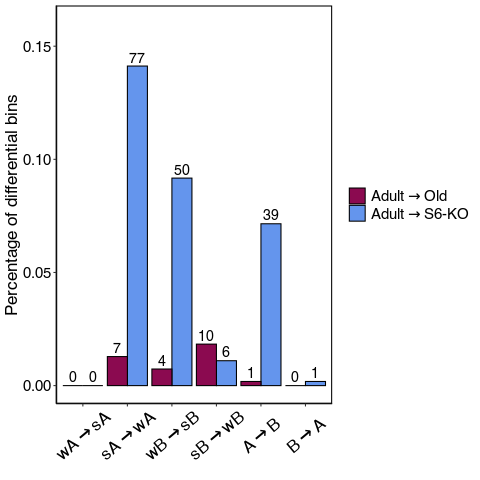

In [17]:
%%R

back = py_eval('bins')

n_bins <- nrow(back)
back <- back %>%
  filter(!grepl('chr[XMY]', chrom))

process_changes <- function(df, type_label, n_total) {
  counts <- c(
    `A->B`   = sum(df$wt >  0 & df$tr <  0),
    `B->A`   = sum(df$wt <  0 & df$tr >  0),
    `wB->sB` = sum(df$wt > df$tr & df$wt <  0 & df$tr < 0),
    `sB->wB` = sum(df$wt < df$tr & df$wt <  0 & df$tr < 0),
    `wA->sA` = sum(df$wt < df$tr & df$wt >  0 & df$tr > 0),
    `sA->wA` = sum(df$wt > df$tr & df$wt >  0 & df$tr > 0)
  )

  data.frame(
    change = names(counts),
    percent = counts / n_total * 100,
    count   = counts,
    type    = type_label,
    stringsAsFactors = FALSE
  )
}

df_list <- list(
  `Adult->S6-KO` = final_df_ko,
  `Adult->Old`   = final_df_old
)

df_all <- bind_rows(
  lapply(names(df_list), function(lbl) {
    process_changes(df_list[[lbl]], lbl, n_bins)
  })
)

df_all$change <- factor(df_all$change, levels = c(
  'wA->sA','sA->wA','wB->sB','sB->wB','A->B','B->A'
))
df_all$type <- factor(df_all$type, levels = c('Adult->Old', 'Adult->S6-KO'))

ggplot(data = df_all, aes(x = change, y = percent, fill = type)) +
  geom_bar(stat = "identity", color = "black", position = position_dodge()) +
  
  geom_text(
    aes(label = count),
    position = position_dodge(width = 0.9),
    vjust = -0.3,
    size = 5
  ) +
  
  ylim(0, 0.16) +
  ylab('Percentage of differential bins') + xlab('') +
  theme_classic() +
  scale_fill_manual(
    values = c('deeppink4','cornflowerblue'),
    labels=c(expression(Adult%->%Old), expression(Adult%->%'S6-KO'))
  ) +
  theme(
    axis.title.y  = element_text(size = 17, colour = 'black'),
    axis.text.x   = element_text(size = 17, colour = 'black', angle = 40, vjust = 0.5),
    axis.text.y   = element_text(size = 15, colour = 'black'),
    legend.title  = element_blank(),
    legend.text   = element_text(size = 15),
    panel.border  = element_rect(colour = "black", fill = NA, size = 1)
  ) +
  scale_x_discrete(labels = c(
    expression(wA %->% sA), expression(sA %->% wA),
    expression(wB %->% sB), expression(sB %->% wB),
    expression(A  %->% B),  expression(B  %->% A)
  ))

In [20]:
## posterior probability > 0.9 and a minimum absolute change of 0.4 in PC1 value

In [18]:
%%R

final_df_old <- process_eigs_data("old", "Old", pp_threshold = 0.9, change_threshold = 0.4)
final_df_ko  <- process_eigs_data("ko",  "S6-KO", pp_threshold = 0.9, change_threshold = 0.4)

  (Intercept) conditiontr
1           1           1
2           1           1
3           1           1
4           1           0
5           1           0
6           1           0
attr(,"assign")
[1] 0 1
attr(,"contrasts")
attr(,"contrasts")$condition
[1] "contr.treatment"

>> preparing features information...		 2026-07-20 04:48:54 PM 
>> identifying nearest features...		 2026-07-20 04:48:54 PM 
>> calculating distance from peak to TSS...	 2026-07-20 04:48:56 PM 
>> assigning genomic annotation...		 2026-07-20 04:48:56 PM 
>> adding gene annotation...			 2026-07-20 04:48:59 PM 
>> adding flank feature information from peaks...	 2026-07-20 04:48:59 PM 
>> assigning chromosome lengths			 2026-07-20 04:48:59 PM 
>> done...					 2026-07-20 04:48:59 PM 
  (Intercept) conditiontr
1           1           1
2           1           1
3           1           1
4           1           0
5           1           0
6           1           0
attr(,"assign")
[1] 0 1
attr(,"contrasts")
attr(,"contras

'select()' returned 1:many mapping between keys and columns
'select()' returned 1:many mapping between keys and columns


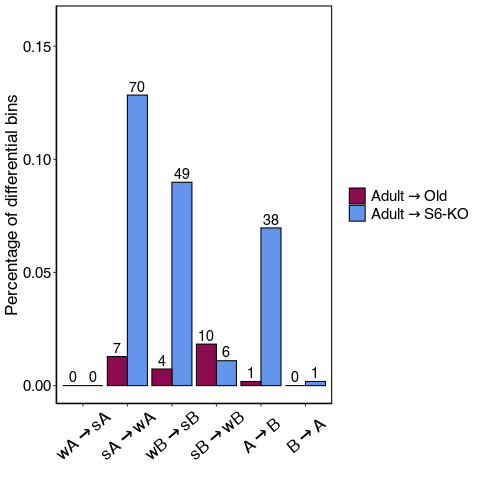

In [19]:
%%R

back = py_eval('bins')

n_bins <- nrow(back)
back <- back %>%
  filter(!grepl('chr[XMY]', chrom))

process_changes <- function(df, type_label, n_total) {
  counts <- c(
    `A->B`   = sum(df$wt >  0 & df$tr <  0),
    `B->A`   = sum(df$wt <  0 & df$tr >  0),
    `wB->sB` = sum(df$wt > df$tr & df$wt <  0 & df$tr < 0),
    `sB->wB` = sum(df$wt < df$tr & df$wt <  0 & df$tr < 0),
    `wA->sA` = sum(df$wt < df$tr & df$wt >  0 & df$tr > 0),
    `sA->wA` = sum(df$wt > df$tr & df$wt >  0 & df$tr > 0)
  )

  data.frame(
    change = names(counts),
    percent = counts / n_total * 100,
    count   = counts,
    type    = type_label,
    stringsAsFactors = FALSE
  )
}

df_list <- list(
  `Adult->S6-KO` = final_df_ko,
  `Adult->Old`   = final_df_old
)

df_all <- bind_rows(
  lapply(names(df_list), function(lbl) {
    process_changes(df_list[[lbl]], lbl, n_bins)
  })
)

df_all$change <- factor(df_all$change, levels = c(
  'wA->sA','sA->wA','wB->sB','sB->wB','A->B','B->A'
))
df_all$type <- factor(df_all$type, levels = c('Adult->Old', 'Adult->S6-KO'))

ggplot(data = df_all, aes(x = change, y = percent, fill = type)) +
  geom_bar(stat = "identity", color = "black", position = position_dodge()) +
  
  geom_text(
    aes(label = count),
    position = position_dodge(width = 0.9),
    vjust = -0.3,
    size = 5
  ) +
  
  ylim(0, 0.16) +
  ylab('Percentage of differential bins') + xlab('') +
  theme_classic() +
  scale_fill_manual(
    values = c('deeppink4','cornflowerblue'),
    labels=c(expression(Adult%->%Old), expression(Adult%->%'S6-KO'))
  ) +
  theme(
    axis.title.y  = element_text(size = 17, colour = 'black'),
    axis.text.x   = element_text(size = 17, colour = 'black', angle = 40, vjust = 0.5),
    axis.text.y   = element_text(size = 15, colour = 'black'),
    legend.title  = element_blank(),
    legend.text   = element_text(size = 15),
    panel.border  = element_rect(colour = "black", fill = NA, size = 1)
  ) +
  scale_x_discrete(labels = c(
    expression(wA %->% sA), expression(sA %->% wA),
    expression(wB %->% sB), expression(sB %->% wB),
    expression(A  %->% B),  expression(B  %->% A)
  ))

In [21]:
## posterior probability > 0.9 and a minimum absolute change of 0.25 in PC1 value

In [22]:
%%R

final_df_old <- process_eigs_data("old", "Old", pp_threshold = 0.9, change_threshold = 0.25)
final_df_ko  <- process_eigs_data("ko",  "S6-KO", pp_threshold = 0.9, change_threshold = 0.25)

  (Intercept) conditiontr
1           1           1
2           1           1
3           1           1
4           1           0
5           1           0
6           1           0
attr(,"assign")
[1] 0 1
attr(,"contrasts")
attr(,"contrasts")$condition
[1] "contr.treatment"

>> preparing features information...		 2026-07-20 04:49:56 PM 
>> identifying nearest features...		 2026-07-20 04:49:56 PM 
>> calculating distance from peak to TSS...	 2026-07-20 04:49:56 PM 
>> assigning genomic annotation...		 2026-07-20 04:49:56 PM 
>> adding gene annotation...			 2026-07-20 04:50:00 PM 
>> adding flank feature information from peaks...	 2026-07-20 04:50:00 PM 
>> assigning chromosome lengths			 2026-07-20 04:50:00 PM 
>> done...					 2026-07-20 04:50:00 PM 
  (Intercept) conditiontr
1           1           1
2           1           1
3           1           1
4           1           0
5           1           0
6           1           0
attr(,"assign")
[1] 0 1
attr(,"contrasts")
attr(,"contras

'select()' returned 1:many mapping between keys and columns
'select()' returned 1:many mapping between keys and columns


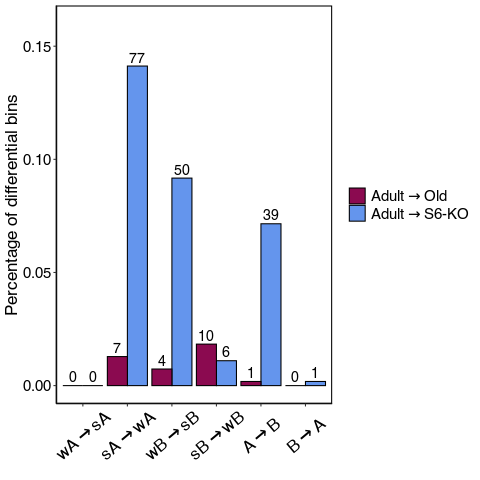

In [23]:
%%R

back = py_eval('bins')

n_bins <- nrow(back)
back <- back %>%
  filter(!grepl('chr[XMY]', chrom))

process_changes <- function(df, type_label, n_total) {
  counts <- c(
    `A->B`   = sum(df$wt >  0 & df$tr <  0),
    `B->A`   = sum(df$wt <  0 & df$tr >  0),
    `wB->sB` = sum(df$wt > df$tr & df$wt <  0 & df$tr < 0),
    `sB->wB` = sum(df$wt < df$tr & df$wt <  0 & df$tr < 0),
    `wA->sA` = sum(df$wt < df$tr & df$wt >  0 & df$tr > 0),
    `sA->wA` = sum(df$wt > df$tr & df$wt >  0 & df$tr > 0)
  )

  data.frame(
    change = names(counts),
    percent = counts / n_total * 100,
    count   = counts,
    type    = type_label,
    stringsAsFactors = FALSE
  )
}

df_list <- list(
  `Adult->S6-KO` = final_df_ko,
  `Adult->Old`   = final_df_old
)

df_all <- bind_rows(
  lapply(names(df_list), function(lbl) {
    process_changes(df_list[[lbl]], lbl, n_bins)
  })
)

df_all$change <- factor(df_all$change, levels = c(
  'wA->sA','sA->wA','wB->sB','sB->wB','A->B','B->A'
))
df_all$type <- factor(df_all$type, levels = c('Adult->Old', 'Adult->S6-KO'))

ggplot(data = df_all, aes(x = change, y = percent, fill = type)) +
  geom_bar(stat = "identity", color = "black", position = position_dodge()) +
  
  geom_text(
    aes(label = count),
    position = position_dodge(width = 0.9),
    vjust = -0.3,
    size = 5
  ) +
  
  ylim(0, 0.16) +
  ylab('Percentage of differential bins') + xlab('') +
  theme_classic() +
  scale_fill_manual(
    values = c('deeppink4','cornflowerblue'),
    labels=c(expression(Adult%->%Old), expression(Adult%->%'S6-KO'))
  ) +
  theme(
    axis.title.y  = element_text(size = 17, colour = 'black'),
    axis.text.x   = element_text(size = 17, colour = 'black', angle = 40, vjust = 0.5),
    axis.text.y   = element_text(size = 15, colour = 'black'),
    legend.title  = element_blank(),
    legend.text   = element_text(size = 15),
    panel.border  = element_rect(colour = "black", fill = NA, size = 1)
  ) +
  scale_x_discrete(labels = c(
    expression(wA %->% sA), expression(sA %->% wA),
    expression(wB %->% sB), expression(sB %->% wB),
    expression(A  %->% B),  expression(B  %->% A)
  ))